# CheXpert Multi-Label Chest X-Ray Classification
## A Minimal CNN-Mamba Hybrid — Script Style

| | |
|---|---|
| **Dataset** | [CheXpert](https://www.kaggle.com/datasets/ashery/chexpert) — chest radiographs labeled for 14 clinical observations, Stanford ML Group |
| **Task** | Multi-label classification (14 independent findings per image) |
| **Approach** | Small CNN feature extractor → selective state-space (Mamba-style) scan → linear classifier |
| **Runtime** | Google Colab, GPU runtime recommended (T4 or better) |
| **Code style** | No custom classes; two `def` functions total (`load_batch`, `forward_pass`); everything else is top-to-bottom script |

### Table of contents
1. [The Mamba algorithm](#1.-The-Mamba-algorithm,-briefly)
2. [Environment setup](#2.-Environment-setup)
3. [Data preparation](#3.-Data-preparation)
4. [Batch loading](#4.-Batch-loading-(def-#1-of-2))
5. [Model parameters and the forward pass](#5.-Model-parameters-and-the-forward-pass-(def-#2-of-2))
6. [Training](#6.-Training)
7. [Evaluation and visual results](#7.-Evaluation-and-visual-results)
8. [Notes](#8.-Notes)

### How this notebook is organized
Each numbered section below is self-contained and runs in order — later sections depend on variables
defined in earlier ones (e.g. Section 6 depends on the layers and `forward_pass` function defined in
Section 5). Re-running a single mid-notebook cell without its predecessors will raise a `NameError`; if
that happens, use **Runtime → Run all** or run the notebook from the top.

## 1. The Mamba algorithm, briefly

Mamba is a **selective state-space model (SSM)**. It processes a sequence of tokens one step at a time,
carrying a hidden state forward like a recurrent network — but the way it updates that state is what makes
it different from a plain RNN.

**The state-space recurrence.** At each step `t`, a hidden state `x_t` is updated from the previous state and
the current input token `u_t`, then read out as an output `y_t`:

```
x_t = A_bar * x_{t-1} + B_bar * u_t
y_t = C * x_t
```

`A_bar` controls how much of the old state is kept, `B_bar` controls how the new token writes into the
state, and `C` controls how the state is read back out.

**The selection mechanism.** Mamba's key idea is to make the step size `Δ`, `B`, and `C` **functions of the
current input token** instead of fixed matrices:

```
delta_t = softplus(Linear(u_t))     # how strongly this token updates the state
B_t     = Linear(u_t)               # how this token writes into the state
C_t     = Linear(u_t)               # how the state is read for this token
A_bar_t = exp(delta_t * A)          # discretized decay, now token-dependent through delta_t
```

Because these vary per token, the model can decide, token by token, "carry this forward" or "let this fade"
— a content-aware behavior a fixed-matrix SSM cannot do. This exact computation is implemented directly
inside the `forward_pass` function documented in Section 5.

**Using it on images.** A CNN reduces the X-ray to a small grid of feature vectors. That grid is flattened
into a sequence of tokens, run through the selective scan above so information mixes across the whole image,
then averaged and passed to a linear classifier with one output per pathology.

**Section summary**

| Term | Role |
|---|---|
| `A` | Learned decay matrix — governs how fast the hidden state forgets |
| `Δ` (delta) | Per-token, learned step size controlling how strongly a token updates the state |
| `B` | Per-token, learned write weights (input → state) |
| `C` | Per-token, learned read weights (state → output) |
| `D` | Direct skip connection from input to output, bypassing the state entirely |

## 2. Environment setup
Installs any missing packages and imports everything the rest of the notebook needs.

In [1]:
# scikit-learn -> AUROC / ROC / classification-report metrics used in Section 7
# seaborn      -> confusion-matrix heatmap styling used in Section 7
!pip install -q scikit-learn seaborn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.3 MB/s eta 0:00:00


In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from tqdm.auto import tqdm

SEED = 42                                    # fixed seed so teammates get comparable results
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Data preparation

**Purpose:** load the CheXpert label CSVs, restrict to frontal-view studies, resolve the uncertain-label
policy, and inspect class balance before any modeling begins.

**Getting the dataset onto Colab** (skip this cell if the dataset is already available on your instance):

```python
from google.colab import files
files.upload()                              # select your kaggle.json when prompted
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ashery/chexpert -p /content/chexpert --unzip
```

**Label policy.** CheXpert labels each of 14 findings as `1` (positive), `0` (negative), `-1` (uncertain), or
blank (not mentioned). Uncertain and missing labels are both mapped to `0` here — a conservative, simple
policy documented explicitly so results can be compared against teams using a different one.

### 3.0 Download the dataset from Kaggle

Run this once per Colab session (the dataset lives on Colab's temporary disk and is wiped when the
runtime disconnects). You'll need a Kaggle API token: Kaggle account -> Settings -> API -> **Create New
Token**, which downloads a `kaggle.json` file -- select that file when the upload prompt below appears.

In [3]:
import os
from google.colab import files

uploaded = files.upload()                          # select your kaggle.json when prompted

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d ashery/chexpert -p /content/chexpert --unzip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [02:02<00:00, 93.8MB/s]



In [4]:
DATA_ROOT = "/content/chexpert"                             # root the dataset was extracted into

csv_matches = glob.glob(os.path.join(DATA_ROOT, "**", "train.csv"), recursive=True)
assert csv_matches, f"train.csv not found under {DATA_ROOT} -- check the download/extraction step"
TRAIN_CSV = csv_matches[0]
VALID_CSV = TRAIN_CSV.replace("train.csv", "valid.csv")

PATHOLOGIES = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly", "Lung Opacity",
    "Lung Lesion", "Edema", "Consolidation", "Pneumonia", "Atelectasis",
    "Pneumothorax", "Pleural Effusion", "Pleural Other", "Fracture",
    "Support Devices",
]
NUM_CLASSES = len(PATHOLOGIES)

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

# The "Path" column looks like "CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg",
# but which folder that prefix maps to on disk varies by how the archive extracted. The last
# four components (train/patientXXXXX/studyN/filename) are always the real, on-disk structure,
# so we locate ONE real file by that suffix and use its location to find every other image --
# no guessing about the "CheXpert-v1.0-small" wrapper folder at all.
suffix = "/".join(train_df.iloc[0]["Path"].split("/")[-4:])          # e.g. "train/patient00001/study1/view1_frontal.jpg"
suffix_matches = glob.glob(os.path.join(DATA_ROOT, "**", suffix), recursive=True)
assert suffix_matches, (
    f"Could not find any file ending in '.../{suffix}' under {DATA_ROOT}. "
    f"Run: !find {DATA_ROOT} -iname 'view1_frontal.jpg' | head -5   to inspect the real layout."
)
IMAGES_ROOT = suffix_matches[0][: -len(suffix)].rstrip("/")            # folder that directly contains train/ and valid/
print(f"Resolved IMAGES_ROOT: {IMAGES_ROOT}")

train_df = train_df[train_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)   # frontal views only
valid_df = valid_df[valid_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)

# Uncertain labels (-1) are mapped to 1 ("U-Ones") for the findings below, following the
# CheXpert paper's policy for observations where uncertainty is common and clinically
# significant; the rest keep the -1 -> 0 policy. Missing values are treated as negative.
U_ONES = {"Atelectasis", "Edema", "Pleural Effusion", "Cardiomegaly", "Consolidation"}

for col in PATHOLOGIES:
    if col in U_ONES:
        train_df[col] = train_df[col].replace(-1, 1)      # uncertain -> positive
        valid_df[col] = valid_df[col].replace(-1, 1)
    else:
        train_df[col] = train_df[col].replace(-1, 0)      # uncertain -> negative
        valid_df[col] = valid_df[col].replace(-1, 0)
    train_df[col] = train_df[col].fillna(0)                 # not-mentioned -> negative either way
    valid_df[col] = valid_df[col].fillna(0)

# Build the real on-disk path for every row from the same last-4-components rule used
# above, then drop any row whose file genuinely isn't there (a handful of images can
# fail to extract from an ~11 GB archive even when the overall extraction looks complete).
train_df["disk_path"] = train_df["Path"].apply(lambda p: os.path.join(IMAGES_ROOT, *p.split("/")[-4:]))
valid_df["disk_path"] = valid_df["Path"].apply(lambda p: os.path.join(IMAGES_ROOT, *p.split("/")[-4:]))

train_exists = train_df["disk_path"].apply(os.path.exists)
valid_exists = valid_df["disk_path"].apply(os.path.exists)
if (~train_exists).sum() or (~valid_exists).sum():
    print(f"Dropping {(~train_exists).sum()} training and {(~valid_exists).sum()} validation "
          f"rows whose image file is missing on disk")
train_df = train_df[train_exists].reset_index(drop=True)
valid_df = valid_df[valid_exists].reset_index(drop=True)

assert len(train_df) > 0 and len(valid_df) > 0, "train_df or valid_df is empty after filtering -- something is still wrong with IMAGES_ROOT."

print(f"Training studies (frontal): {len(train_df)}")
print(f"Validation studies (frontal): {len(valid_df)}")
train_df.head()

Resolved IMAGES_ROOT: /content/chexpert
Training studies (frontal): 191027
Validation studies (frontal): 202


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,disk_path
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,/content/chexpert/train/patient00001/study1/vi...
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,/content/chexpert/train/patient00002/study2/vi...
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,/content/chexpert/train/patient00002/study1/vi...
3,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/chexpert/train/patient00003/study1/vi...
4,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/chexpert/train/patient00004/study1/vi...


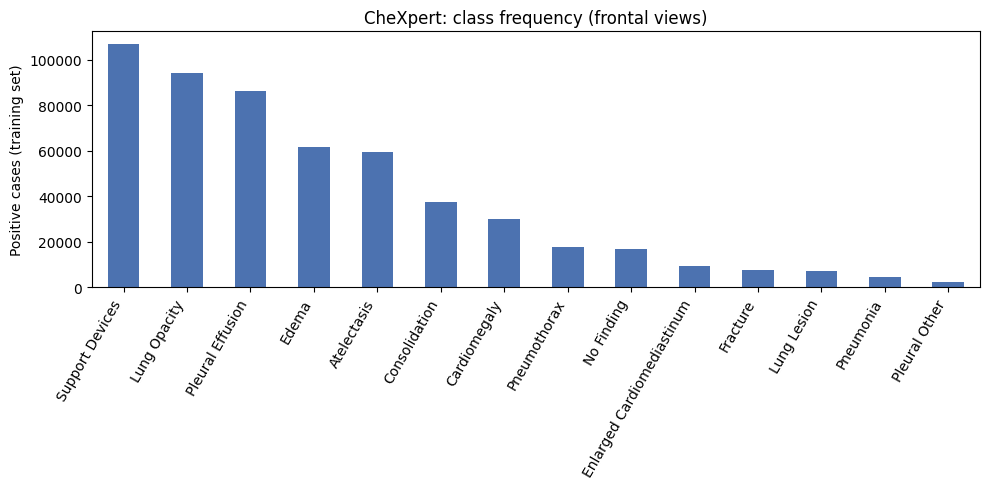

In [5]:
# Class balance check -- medical labels are highly imbalanced, which is why AUROC (not
# accuracy) is used for evaluation later.
class_counts = train_df[PATHOLOGIES].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar", color="#4C72B0")
plt.ylabel("Positive cases (training set)")
plt.title("CheXpert: class frequency (frontal views)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [6]:
IMG_SIZE = 128   # kept modest so the per-token scan loop in Section 5 stays fast

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),                                       # chest anatomy is roughly left-right symmetric
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),   # ImageNet statistics, standard for this normalization range
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## 4. Batch loading (`def` #1 of 2)

**Purpose:** replace the usual `Dataset`/`DataLoader` classes with a single plain function that reads a
batch of images and labels from disk on demand. It is defined once here and called every training and
validation step in Sections 6–7.

In [7]:
def load_batch(dataframe, indices, transform):
    """
    Load one batch of CheXpert images and labels from disk.

    Args:
        dataframe (pd.DataFrame): Label table (train_df or valid_df) to read rows from.
            Must include the "disk_path" column added during data preparation.
        indices (array-like of int): Row positions (via .iloc) to include in this batch.
        transform (torchvision.transforms.Compose): Resize/augmentation/normalization
            pipeline applied to each image (train_transform or val_transform).

    Returns:
        image_batch (torch.FloatTensor): Shape (len(indices), 3, IMG_SIZE, IMG_SIZE).
        label_batch (torch.FloatTensor): Shape (len(indices), NUM_CLASSES), multi-hot.
    """
    images, labels = [], []
    for idx in indices:
        row = dataframe.iloc[idx]
        image = Image.open(row["disk_path"]).convert("RGB")
        images.append(transform(image))
        labels.append(row[PATHOLOGIES].values.astype("float32"))
    image_batch = torch.stack(images)
    label_batch = torch.tensor(np.stack(labels))
    return image_batch, label_batch

## 5. Model parameters and the forward pass (`def` #2 of 2)

**Purpose:** define every learnable layer as a plain variable (no wrapping class), then define
`forward_pass`, the single function that threads a batch of images through the CNN and the selective-scan
computation from Section 1 to produce classification logits.

Creating an `nn.Conv2d` or `nn.Linear` instantiates a class PyTorch already provides — it does not define a
new one, so this section still contains zero custom classes.

In [8]:
D_MODEL = 128     # channel width of the CNN's output / the Mamba token width
D_STATE = 8       # size of the selective-scan hidden state per channel

# CNN feature extractor: four stride-2 conv layers turn a 128x128 image into an 8x8 grid
# of D_MODEL-channel features (128 / 2^4 = 8).
conv1, bn1 = nn.Conv2d(3, 32, 3, stride=2, padding=1).to(DEVICE), nn.BatchNorm2d(32).to(DEVICE)
conv2, bn2 = nn.Conv2d(32, 64, 3, stride=2, padding=1).to(DEVICE), nn.BatchNorm2d(64).to(DEVICE)
conv3, bn3 = nn.Conv2d(64, 128, 3, stride=2, padding=1).to(DEVICE), nn.BatchNorm2d(128).to(DEVICE)
conv4, bn4 = nn.Conv2d(128, D_MODEL, 3, stride=2, padding=1).to(DEVICE), nn.BatchNorm2d(D_MODEL).to(DEVICE)

# Selective state-space parameters (Section 1): Delta, B, and C are produced from each
# token by these linear layers, which is what makes the scan "selective" / input-dependent.
delta_proj = nn.Linear(D_MODEL, D_MODEL).to(DEVICE)
B_proj = nn.Linear(D_MODEL, D_STATE).to(DEVICE)
C_proj = nn.Linear(D_MODEL, D_STATE).to(DEVICE)

# A is stored in log-space and kept negative via -exp(...), so the state decays rather
# than explodes at the start of training -- the same stabilizing trick S4/Mamba use.
# BUG FIX: build the tensor directly on DEVICE, then wrap it -- nn.Parameter(...).to(DEVICE)
# would silently detach it from the optimizer (it stops receiving gradients).
A_init = torch.arange(1, D_STATE + 1, dtype=torch.float32, device=DEVICE).repeat(D_MODEL, 1)
A_log = nn.Parameter(torch.log(A_init))
D_skip = nn.Parameter(torch.ones(D_MODEL, device=DEVICE))     # direct skip term, like a residual connection

classifier = nn.Linear(D_MODEL, NUM_CLASSES).to(DEVICE)         # one logit per pathology

# All learnable tensors, collected once so the optimizer can update every one of them.
PARAMS = (list(conv1.parameters()) + list(bn1.parameters()) +
          list(conv2.parameters()) + list(bn2.parameters()) +
          list(conv3.parameters()) + list(bn3.parameters()) +
          list(conv4.parameters()) + list(bn4.parameters()) +
          list(delta_proj.parameters()) + list(B_proj.parameters()) + list(C_proj.parameters()) +
          [A_log, D_skip] + list(classifier.parameters()))

print(f"Trainable parameters: {sum(p.numel() for p in PARAMS):,}")

Trainable parameters: 263,070


In [9]:
def forward_pass(images):
    '''
    Run a batch of chest X-rays through the CNN backbone and the selective state-space
    scan, returning raw multi-label classification logits.

    Args:
        images (torch.FloatTensor): Shape (batch, 3, IMG_SIZE, IMG_SIZE), normalized
            image batch as produced by load_batch.

    Returns:
        torch.FloatTensor: Shape (batch, NUM_CLASSES). Raw logits (sigmoid is applied
            separately, inside BCEWithLogitsLoss during training and via torch.sigmoid
            during evaluation).

    Notes:
        Uses the layers and parameters defined earlier in Section 5 (conv1..conv4, bn1..bn4,
        delta_proj, B_proj, C_proj, A_log, D_skip, classifier) as closures rather than
        arguments, since this function is only ever called with the one set of weights
        this notebook trains.
    '''
    x = F.relu(bn1(conv1(images)))
    x = F.relu(bn2(conv2(x)))
    x = F.relu(bn3(conv3(x)))
    x = F.relu(bn4(conv4(x)))                              # (batch, D_MODEL, 8, 8)

    b, c, h, w = x.shape
    tokens = x.flatten(2).transpose(1, 2)                    # (batch, 64, D_MODEL) -- one token per spatial cell

    A = -torch.exp(A_log)                                      # (D_MODEL, D_STATE), kept negative for stability
    delta = F.softplus(delta_proj(tokens))                       # (batch, tokens, D_MODEL), input-dependent step size
    B = B_proj(tokens)                                            # (batch, tokens, D_STATE), input-dependent write
    C = C_proj(tokens)                                             # (batch, tokens, D_STATE), input-dependent read

    A_bar = torch.exp(delta.unsqueeze(-1) * A)                      # discretized decay, per token
    B_bar = delta.unsqueeze(-1) * B.unsqueeze(2)                      # discretized input weighting, per token

    state = torch.zeros(b, c, D_STATE, device=images.device)          # hidden state starts at zero
    outputs = []
    for t in range(tokens.shape[1]):                                    # sequential scan across the 64 tokens
        state = A_bar[:, t] * state + B_bar[:, t] * tokens[:, t].unsqueeze(-1)
        outputs.append((state * C[:, t].unsqueeze(1)).sum(dim=-1))
    scanned = torch.stack(outputs, dim=1) + tokens * D_skip              # add the skip term (Section 1)

    pooled = scanned.mean(dim=1)                                          # average over all tokens
    return classifier(pooled)                                             # (batch, NUM_CLASSES) raw logits

## 6. Training

**Purpose:** optimize every parameter in `PARAMS` against the multi-label binary cross-entropy loss,
tracking training/validation loss and validation AUROC once per epoch.

**Configuration used in this run**

| Hyperparameter | Value | Notes |
|---|---|---|
| `EPOCHS` | 8 | Increase once the pipeline is validated end-to-end |
| `BATCH_SIZE` | 32 | Reduce if you hit CUDA out-of-memory |
| `LEARNING_RATE` | 1e-4 | AdamW optimizer, no LR schedule |
| Loss | `BCEWithLogitsLoss` | Independent sigmoid per pathology (multi-label, not multi-class) |
| Gradient clipping | max norm 1.0 | Stabilizes the recurrent scan's gradients |

In [10]:
EPOCHS = 8
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

criterion = nn.BCEWithLogitsLoss()             # multi-label loss: independent sigmoid per pathology
optimizer = torch.optim.AdamW(PARAMS, lr=LEARNING_RATE)

train_losses = []
valid_losses = []
valid_auroc_history = []

In [11]:
# Flat training loop: batches are built by hand with load_batch/forward_pass rather than
# a DataLoader, and there is no separate train_one_epoch()/validate() function -- the whole
# procedure reads top to bottom for each epoch.
for epoch in range(1, EPOCHS + 1):

    train_order = np.random.permutation(len(train_df))            # reshuffle each epoch
    running_loss = 0.0
    for start in tqdm(range(0, len(train_order) - BATCH_SIZE + 1, BATCH_SIZE),
                       desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        batch_idx = train_order[start:start + BATCH_SIZE]
        images, labels = load_batch(train_df, batch_idx, train_transform)
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = forward_pass(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(PARAMS, max_norm=1.0)         # keeps the recurrent scan's gradients stable
        optimizer.step()

        running_loss += loss.item() * len(batch_idx)
    # BUG FIX: match the denominator to the examples actually processed (the final
    # partial batch is dropped, same as the validation loop below).
    train_losses.append(running_loss / (len(train_order) - len(train_order) % BATCH_SIZE))

    valid_order = np.arange(len(valid_df))                            # no shuffling needed for validation
    running_val_loss = 0.0
    all_probs, all_targets = [], []
    with torch.no_grad():
        for start in tqdm(range(0, len(valid_order) - BATCH_SIZE + 1, BATCH_SIZE),
                           desc=f"Epoch {epoch}/{EPOCHS} [valid]"):
            batch_idx = valid_order[start:start + BATCH_SIZE]
            images, labels = load_batch(valid_df, batch_idx, val_transform)
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            logits = forward_pass(images)
            running_val_loss += criterion(logits, labels).item() * len(batch_idx)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(labels.cpu().numpy())
    valid_losses.append(running_val_loss / (len(valid_order) - len(valid_order) % BATCH_SIZE))

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    per_class_auroc = [roc_auc_score(all_targets[:, c], all_probs[:, c])
                        for c in range(NUM_CLASSES) if len(np.unique(all_targets[:, c])) > 1]
    mean_auroc = float(np.mean(per_class_auroc)) if per_class_auroc else float("nan")
    valid_auroc_history.append(mean_auroc)

    print(f"Epoch {epoch}: train_loss={train_losses[-1]:.4f} | "
          f"val_loss={valid_losses[-1]:.4f} | val_mean_AUROC={mean_auroc:.4f}")

Epoch 1/8 [train]:   0%|          | 0/5969 [00:00<?, ?it/s]

Epoch 1/8 [valid]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1: train_loss=0.3711 | val_loss=0.4521 | val_mean_AUROC=0.7108


Epoch 2/8 [train]:   0%|          | 0/5969 [00:00<?, ?it/s]

Epoch 2/8 [valid]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Epoch 7/8 [valid]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 7: train_loss=0.3410 | val_loss=0.4104 | val_mean_AUROC=0.7606


Epoch 8/8 [train]:   0%|          | 0/5969 [00:00<?, ?it/s]

Epoch 8/8 [valid]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 8: train_loss=0.3393 | val_loss=0.4276 | val_mean_AUROC=0.7722


## 7. Evaluation and visual results

**Purpose:** quantify final model performance with the standard multi-label metric for this literature
(per-class AUROC), then inspect results visually via ROC curves, a confusion matrix for a clinically
significant class, and qualitative predictions on sample images.

### 7.1 Learning curves

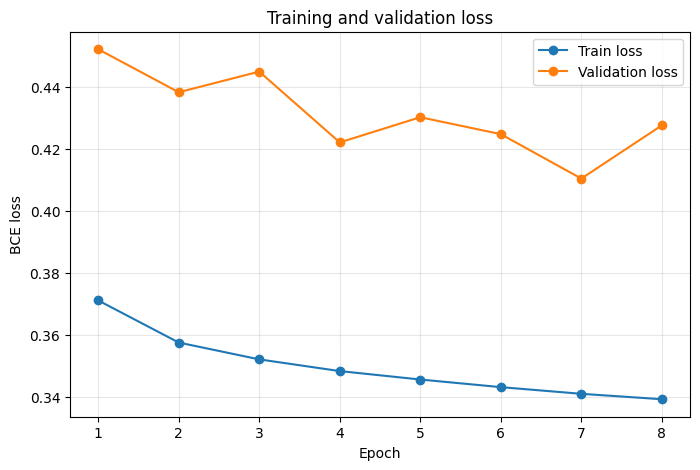

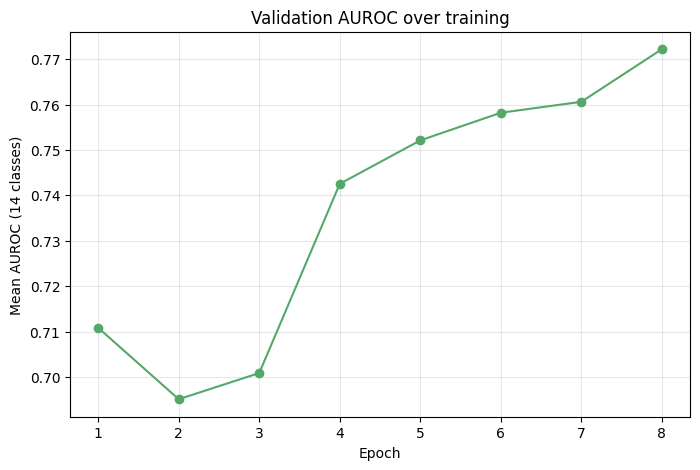

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train loss")
plt.plot(range(1, EPOCHS + 1), valid_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("BCE loss"); plt.title("Training and validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), valid_auroc_history, marker="o", color="#55A868")
plt.xlabel("Epoch"); plt.ylabel("Mean AUROC (14 classes)"); plt.title("Validation AUROC over training")
plt.grid(alpha=0.3); plt.show()

### 7.2 Final per-class AUROC

In [13]:
# Final per-class AUROC table, computed over the full validation set.
valid_order = np.arange(len(valid_df))
final_probs, final_targets = [], []
with torch.no_grad():
    for start in tqdm(range(0, len(valid_order) - BATCH_SIZE + 1, BATCH_SIZE), desc="Final evaluation"):
        batch_idx = valid_order[start:start + BATCH_SIZE]
        images, labels = load_batch(valid_df, batch_idx, val_transform)
        logits = forward_pass(images.to(DEVICE))
        final_probs.append(torch.sigmoid(logits).cpu().numpy())
        final_targets.append(labels.numpy())
final_probs = np.concatenate(final_probs, axis=0)
final_targets = np.concatenate(final_targets, axis=0)

results = []
for c, name in enumerate(PATHOLOGIES):
    auroc = roc_auc_score(final_targets[:, c], final_probs[:, c]) if len(np.unique(final_targets[:, c])) > 1 else float("nan")
    results.append({"Pathology": name, "AUROC": auroc, "Positive cases": int(final_targets[:, c].sum())})

results_df = pd.DataFrame(results).sort_values("AUROC", ascending=False).reset_index(drop=True)
results_df

Final evaluation:   0%|          | 0/6 [00:00<?, ?it/s]

,Pathology,AUROC,Positive cases
0,Pleural Other,0.947644,1
1,No Finding,0.892261,26
2,Edema,0.884196,39
3,Consolidation,0.879883,32
4,Lung Opacity,0.850962,111
5,Pleural Effusion,0.845946,63
6,Pneumothorax,0.808494,7
7,Cardiomegaly,0.801514,64
8,Atelectasis,0.787847,72
9,Support Devices,0.722192,95


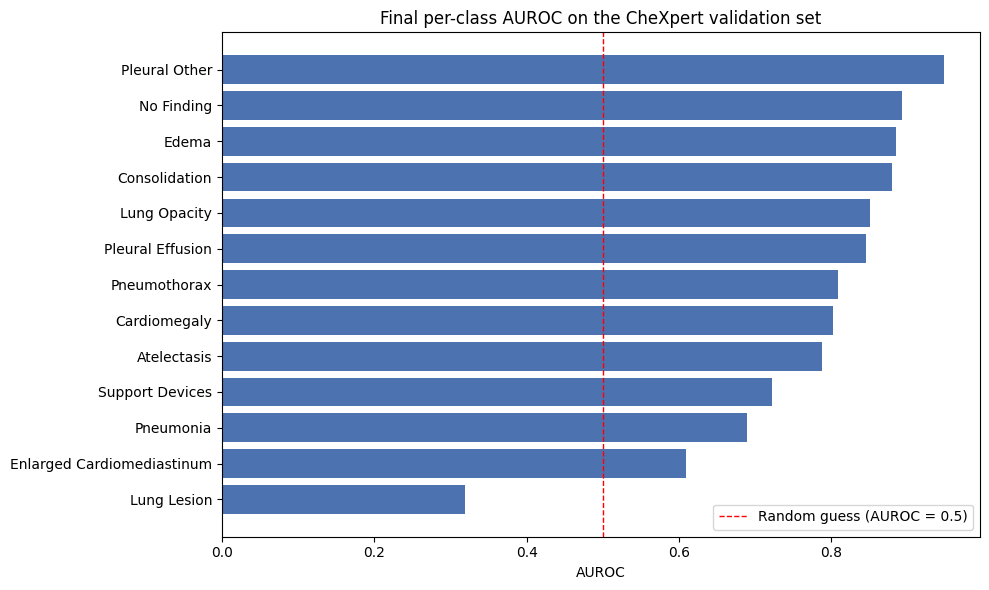

In [14]:
plotted = results_df.dropna(subset=["AUROC"])
plt.figure(figsize=(10, 6))
plt.barh(plotted["Pathology"], plotted["AUROC"], color="#4C72B0")
plt.axvline(0.5, color="red", linestyle="--", linewidth=1, label="Random guess (AUROC = 0.5)")
plt.xlabel("AUROC"); plt.title("Final per-class AUROC on the CheXpert validation set")
plt.legend(); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### 7.3 ROC curves

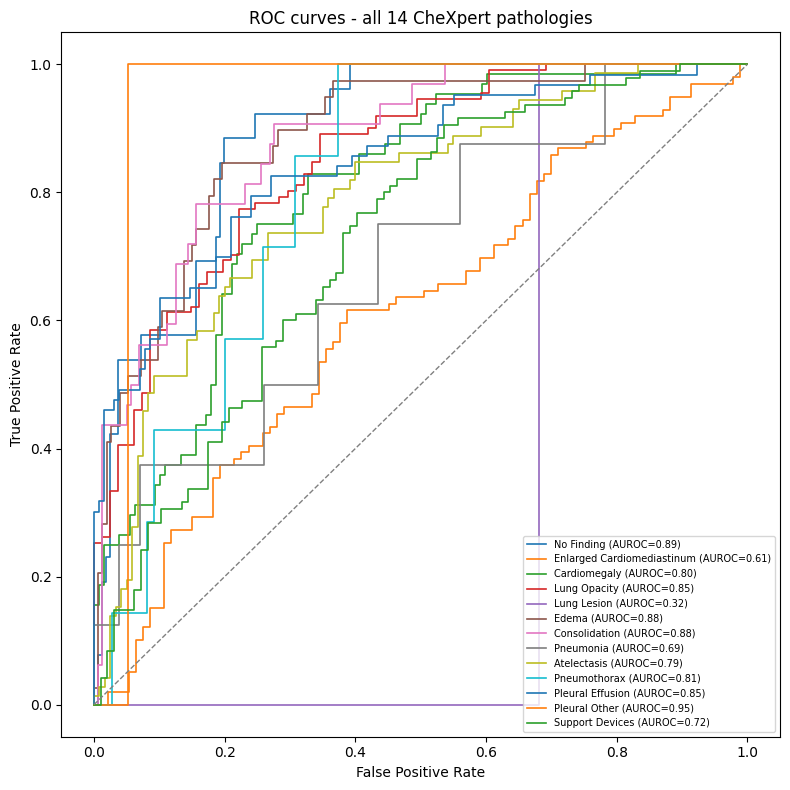

In [15]:
plt.figure(figsize=(8, 8))
for c, name in enumerate(PATHOLOGIES):
    if len(np.unique(final_targets[:, c])) > 1:
        fpr, tpr, _ = roc_curve(final_targets[:, c], final_probs[:, c])
        auroc = roc_auc_score(final_targets[:, c], final_probs[:, c])
        plt.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.2f})", linewidth=1.2)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves - all 14 CheXpert pathologies")
plt.legend(fontsize=7, loc="lower right"); plt.tight_layout(); plt.show()

### 7.4 Confusion matrix (Cardiomegaly, threshold = 0.5)

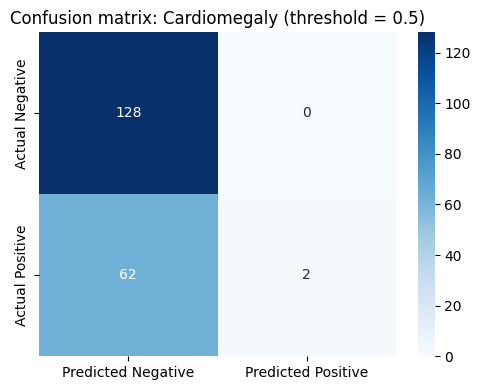

              precision    recall  f1-score   support

    Negative       0.67      1.00      0.81       128
    Positive       1.00      0.03      0.06        64

    accuracy                           0.68       192
   macro avg       0.84      0.52      0.43       192
weighted avg       0.78      0.68      0.56       192



In [16]:
TARGET_CLASS = "Cardiomegaly"
c_idx = PATHOLOGIES.index(TARGET_CLASS)
preds_binary = (final_probs[:, c_idx] >= 0.5).astype(int)
cm = confusion_matrix(final_targets[:, c_idx], preds_binary)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title(f"Confusion matrix: {TARGET_CLASS} (threshold = 0.5)")
plt.tight_layout(); plt.show()

print(classification_report(final_targets[:, c_idx], preds_binary, target_names=["Negative", "Positive"]))

### 7.5 Qualitative predictions

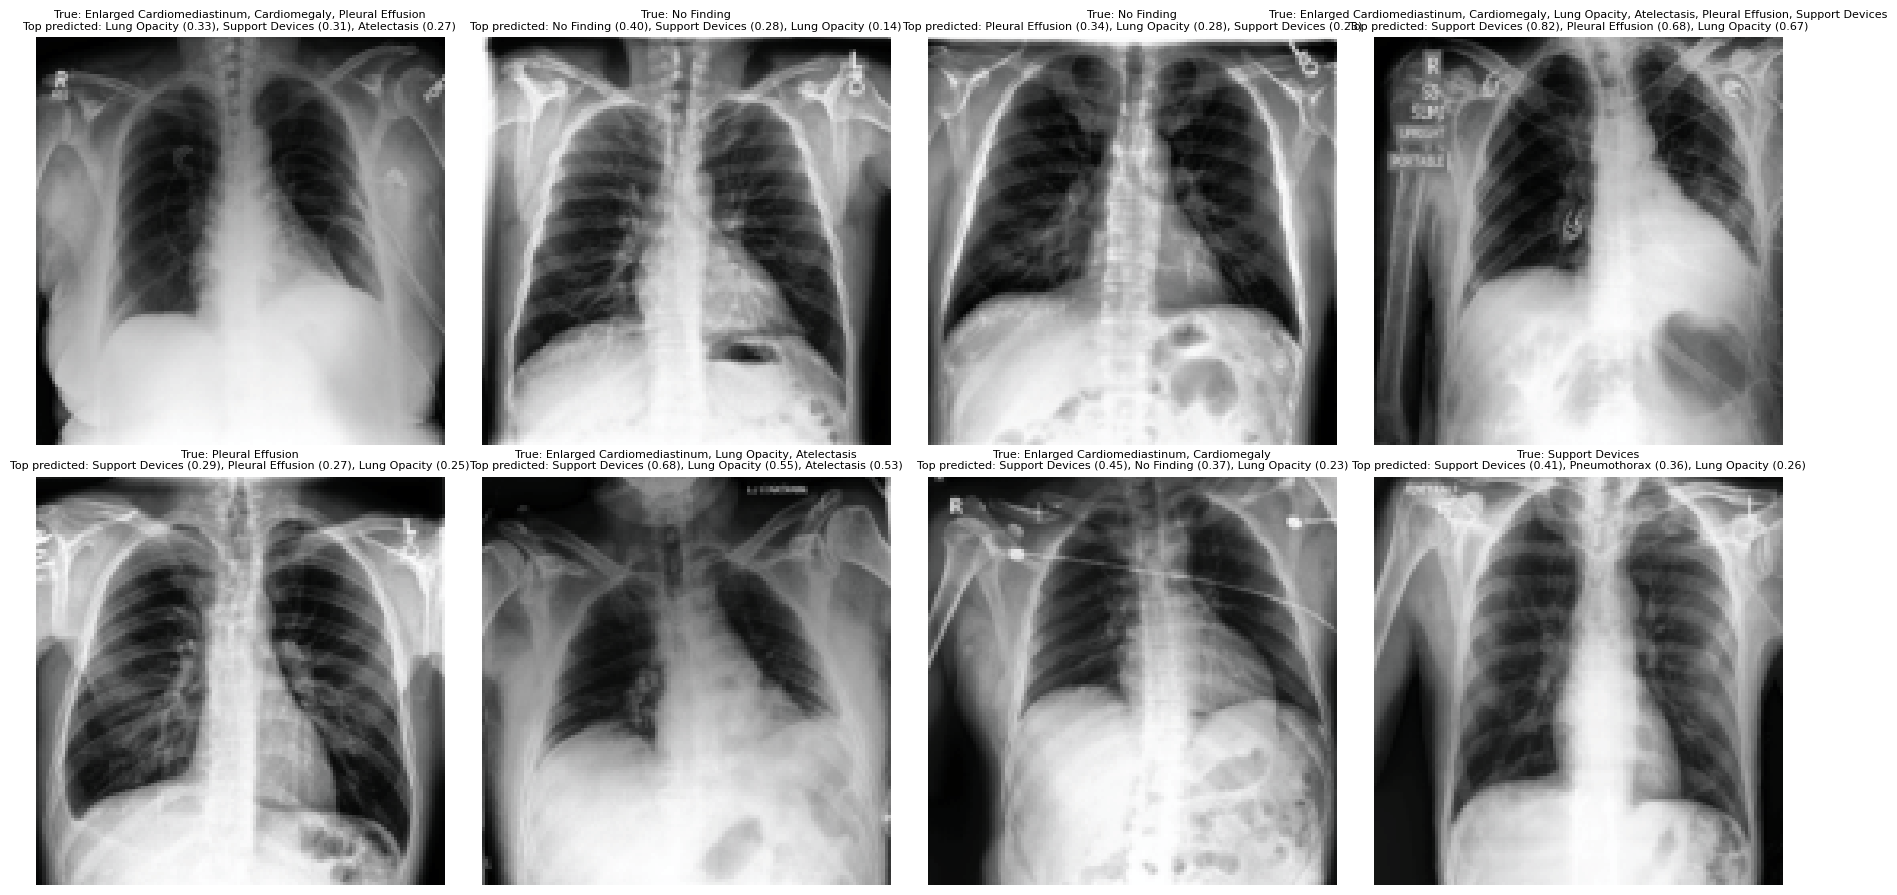

In [17]:
# A few validation images with true vs. predicted labels, for a sanity check beyond the metrics above.
NUM_SAMPLES = 8
sample_indices = np.random.choice(len(valid_df), size=NUM_SAMPLES, replace=False)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

images, labels = load_batch(valid_df, sample_indices, val_transform)
with torch.no_grad():
    probs = torch.sigmoid(forward_pass(images.to(DEVICE))).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, image_tensor, label_vec, prob_vec in zip(axes, images, labels.numpy(), probs):
    img_display = image_tensor.permute(1, 2, 0).numpy()
    img_display = np.clip(img_display * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

    true_labels = [PATHOLOGIES[i] for i in range(NUM_CLASSES) if label_vec[i] == 1]
    top3_idx = prob_vec.argsort()[-3:][::-1]
    pred_labels = [f"{PATHOLOGIES[i]} ({prob_vec[i]:.2f})" for i in top3_idx]

    ax.imshow(img_display)
    ax.set_title(f"True: {', '.join(true_labels) or 'No Finding'}\nTop predicted: {', '.join(pred_labels)}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Notes

- **Why only two functions:** `load_batch` and `forward_pass` are each called dozens of times per epoch;
  writing either one out inline at every call site would make the training loop far harder to read. Every
  other step in this notebook happens exactly where it's used, once, in plain script form.
- **No `DataLoader`/multiprocessing:** batches are built by direct indexing into the DataFrame, which is
  simple to read but single-threaded. If data loading becomes the bottleneck, this is the natural place to
  add parallel workers back in.
- **If you want more accuracy later:** swap the CNN layers for a pretrained backbone's weights, add more
  than one selective-scan pass back to back, or use a less conservative uncertainty-label policy.
- **Evaluate on the official test set** before drawing conclusions — the public validation split here is
  useful for development but is not the benchmark Stanford uses.